In the name of God

Seyed Mani Mirshabani 810801080

# Q2: Vision Language Models (VLMs)

# S1: VLM Anatomy

**Objective:** In this section, you will learn the anatomy of Vision-Language Models (VLMs), identify their core components, and practically explore how images are translated into tokens that a Large Language Model (LLM) can process.

## 1. Model Anatomy





A typical Vision-Language Model usually consists of three main components:

- **Vision Encoder:** A neural network (often a Vision Transformer or ViT) that processes the raw image to extract visual features.
- **Vision-Language Projector:** Linear layers or MLPs that map the extracted visual features into the same dimensional space as the text tokens.
- **Large Language Model:** The core LLM that processes the combined sequence of text and visual tokens to generate an output.



### Task 1.1: Load and Inspect the Model



#### Import Libraries

In [1]:
pip install qwen-vl-utils

In [2]:
import time
import random
import torch
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import (
    AutoProcessor,
    AutoModelForCausalLM,
    AutoModelForMultimodalLM,
    TrainingArguments,
    Trainer
)
from peft import LoraConfig, get_peft_model
from qwen_vl_utils import process_vision_info

Complete and run the code cell below to use the transformers library to load the Qwen/Qwen3.5-0.8B model and its processor, and print the underlying model architecture.


In [3]:
model_id = "Qwen/Qwen3.5-0.8B"

# TODO: Load processor
processor = AutoProcessor.from_pretrained(model_id)

# TODO: Load model (use bfloat16 or float16 to save memory)
model = AutoModelForMultimodalLM.from_pretrained(
    model_id,
    torch_dtype=torch.bfloat16,
    device_map="auto"
)

print(model)

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

Qwen3_5ForConditionalGeneration(
  (model): Qwen3_5Model(
    (visual): Qwen3_5VisionModel(
      (patch_embed): Qwen3_5VisionPatchEmbed(
        (proj): Conv3d(3, 768, kernel_size=(2, 16, 16), stride=(2, 16, 16))
      )
      (pos_embed): Embedding(2304, 768)
      (rotary_pos_emb): Qwen3_5VisionRotaryEmbedding()
      (blocks): ModuleList(
        (0-11): 12 x Qwen3_5VisionBlock(
          (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (attn): Qwen3_5VisionAttention(
            (qkv): Linear(in_features=768, out_features=2304, bias=True)
            (proj): Linear(in_features=768, out_features=768, bias=True)
          )
          (mlp): Qwen3_5VisionMLP(
            (linear_fc1): Linear(in_features=768, out_features=3072, bias=True)
            (linear_fc2): Linear(in_features=3072, out_features=768, bias=True)
            (act_fn): GELUTanh()
          )
        )
      )
      (mer

**Question 1.1:** Inspect the printed model architecture layout above. Identify and write down the exact module or class names corresponding to the Vision Encoder, the Projector, and the Large Language Model components.


**Student's Answer:**

*italicized text*

Based on the outputs, the names of the components are:

* Vision Encoder: Qwen3_5VisionModel
* Vision Language Projector: Qwen3_5VisionPatchMerger (it converts the visual features to model embeddings with dimension of 1024)
* LLM: Qwen3_5TextModel

## 2. Baseline Inference

Let's test the model on real data to see how it performs. We will break this down into three steps: loading data, formatting the multimodal prompts, and generating the responses.

### Important Note: Non-Thinking Mode

For all evaluations and fine-tuning tasks in this notebook, you must set the model to **Non-thinking mode** to test its pure Instruct behavior.

For technical details, check the [Hugging Face Qwen3.5 Documentation](https://huggingface.co/Qwen/Qwen3.5-0.8B).


### Task 1.2a: Load and Explore the Dataset

Complete and run the code below to load the ScienceQA dataset, filter it for samples containing image, and select 3 samples of your choice.

In [4]:
dataset = load_dataset("derek-thomas/ScienceQA")

# TODO: Filter the 'train' split to keep ONLY samples with an 'image'
image_data = dataset["train"].filter(lambda x: x["image"] is not None)

# TODO: Select 3 samples of your choice from image_data
selected_samples = image_data.select([0, 1, 2])
print(selected_samples)

Dataset({
    features: ['image', 'question', 'choices', 'answer', 'hint', 'task', 'grade', 'subject', 'topic', 'category', 'skill', 'lecture', 'solution'],
    num_rows: 3
})


### Task 1.2b: Format the Multimodal Prompts

VLMs require structural preprocessing to combine image arrays and text strings into a unified sequence. Complete and run the cell below to apply the chat template and process the multimodal sequence for the selected evaluation samples.


In [5]:
prepared_samples = []

for sample in selected_samples:
    question = sample['question']
    choices = sample['choices']
    answer_idx = sample['answer']

    ground_truth = str(choices[answer_idx]).strip()
    choices_text = "\n".join([f"- {c}" for c in choices])
    full_prompt = f"{question}\nChoices:\n{choices_text}\nAnswer concisely with the correct choice."

    # TODO: Build the messages list (user role, containing image and text)
    messages = [
        {
            "role": "system",
            "content": [{"type": "text", "text": "You are a helpful and harmless assistant. You are Qwen developed by Alibaba Cloud. Please answer directly."}]
        },
        {
            "role": "user",
            "content": [
                {"type": "image", "image": sample["image"]},
                {"type": "text", "text": full_prompt}
            ]
        }
    ]

    # TODO: Apply chat template
    text = processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )

    # TODO: Extract image inputs using process_vision_info
    image_inputs, _ = process_vision_info(messages)

    # TODO: Get final inputs using processor
    inputs = processor(
        text=[text],
        images=image_inputs,
        padding=True,
        return_tensors="pt"
    )

    prepared_samples.append({
        "inputs": inputs,
        "image": sample["image"],
        "prompt": full_prompt,
        "ground_truth": ground_truth
    })

print(f"Successfully formatted {len(prepared_samples)} prompts.")

Successfully formatted 3 prompts.


### Task 1.2c: Generate and Decode

In this task, you will execute the baseline generation. Complete and run the loop below to feed the preprocessed inputs into the model, extract the newly generated IDs, and decode them into readable text answers.

**Note:** You must write your code to explicitly display the Image, the Text Prompt/Question, the Ground Truth Answer, and the generated Model Output sequentially for each sample. This is a mandatory step to directly assess and verify the VLM's inference capabilities.


[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


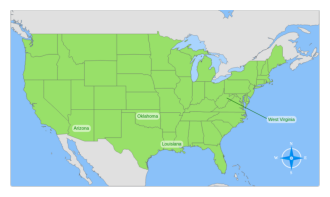

[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


Prompt: Which of these states is farthest north?
Choices:
- West Virginia
- Louisiana
- Arizona
- Oklahoma
Answer concisely with the correct choice.
Ground Truth: West Virginia
Model Output: West Virginia

--------------------------------------------------


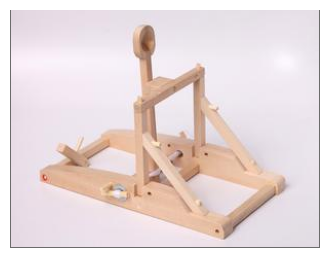

[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


Prompt: Identify the question that Tom and Justin's experiment can best answer.
Choices:
- Do ping pong balls stop rolling along the ground sooner after being launched from a 30° angle or a 45° angle?
- Do ping pong balls travel farther when launched from a 30° angle compared to a 45° angle?
Answer concisely with the correct choice.
Ground Truth: Do ping pong balls travel farther when launched from a 30° angle compared to a 45° angle?
Model Output: The image shows a wooden apparatus with a circular base and a vertical post, which resembles a simple physics experiment setup for projectile motion. The question asks about the effect of launch angle on the distance traveled by ping pong balls.

- Choice 1:
--------------------------------------------------


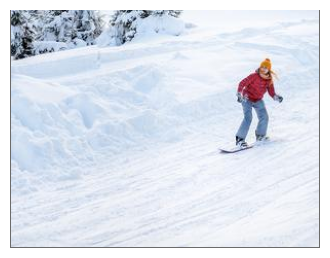

Prompt: Identify the question that Kathleen and Bryant's experiment can best answer.
Choices:
- Does Kathleen's snowboard slide down a hill in less time when it has a layer of wax or when it does not have a layer of wax?
- Does Kathleen's snowboard slide down a hill in less time when it has a thin layer of wax or a thick layer of wax?
Answer concisely with the correct choice.
Ground Truth: Does Kathleen's snowboard slide down a hill in less time when it has a layer of wax or when it does not have a layer of wax?
Model Output: The question that Kathleen and Bryant's experiment can best answer is:

**Does Kathleen's snowboard slide down a hill in less time when it has a layer of wax or when it does not have a layer of wax?**

This is because the
--------------------------------------------------


In [6]:
for sample_data in prepared_samples:
    # Safely move inputs to the same device as the model
    inputs = sample_data["inputs"].to(model.device)

    # TODO: Generate output IDs using the model (inside torch.no_grad())
    with torch.no_grad():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=50
        )

    # TODO: Decode ONLY the newly generated tokens to text
    input_length = inputs.input_ids.shape[1]
    generated_ids_trimmed = generated_ids[:, input_length:]

    output_text = processor.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True
    )[0]

    # Display results
    plt.figure(figsize=(4, 4))
    plt.imshow(sample_data["image"])
    plt.axis("off")
    plt.show()
    print(f"Prompt: {sample_data['prompt']}\nGround Truth: {sample_data['ground_truth']}\nModel Output: {output_text}\n" + "-"*50)

## 3. Playing with Tokens: Analyzing the Input Sequence

When a VLM encounters an image, it converts the picture into a series of 'visual tokens' and integrates them with the text tokens, forming a single prompt for the LLM.

### Task 1.3: Structural Token Analysis

Complete the cell below to inspect the input_ids tensor generated from the last processed sample. Your task is to use this tensor to calculate the exact number of visual tokens and text tokens present in the sequence.

In [7]:
input_ids = inputs.input_ids

# TODO: Find the token ID for image pads
image_token_id = processor.tokenizer.convert_tokens_to_ids("<|image_pad|>")

# TODO: Count visual tokens and text tokens
num_visual_tokens = (input_ids == image_token_id).sum().item()
num_text_tokens = input_ids.numel() - num_visual_tokens

print(f"Visual Tokens: {num_visual_tokens} | Text Tokens: {num_text_tokens}")

Visual Tokens: 70 | Text Tokens: 128


**Question 1.3a (Empirical Analysis):** Review the printed token counts from the code execution above. Calculate the exact percentage of the total input sequence length ($N$) that is occupied by the visual tokens versus the textual tokens. What does this distribution tell you about how a VLM allocates its processing capacity compared to a text-only LLM?

**Student's Answer:**


The total number of toeks are 70 + 128 = 198

So visual tokens take about 35% and text tokens take about 65%.

This distribution tells us that even for a simple task and only one image, a good portion (35%) of the tokens are allocated to the image. In a text only LLM, all the processing power goes to linguistic reasoning but in a VLM, the model needs to allocated a noticable portion of to the visual data.

This shows that visual processing takes a considerable part of the computational resources and leaves less capacity for textual processing like reasoning or maintaining longer contexts compared to text only models.

**Question 1.3b (Mathematical Complexity Analysis):** Consider the standard computational cost formula per forward pass for a single Transformer processing an input sequence:

$$\text{Total FLOPs} = T \times (4nd^2 + 2n^2d + 2ndm)$$

Where:

- $n$ is the sequence length (total number of tokens).
- $d$ is the model's hidden embedding dimension size.
- $m$ is the intermediate dimension size of the MLP layer.
- $T$ is the number of transformer blocks/layers.

Based on this formula and the token counts you extracted in Task 1.3, identify which specific term inside the parentheses poses the greatest computational threat when shifting from a text-only LLM to a Vision-Language Model. Explain why processing visual data scales the computational overhead so aggressively.

**Student's Answer:**


The most important term for us is 2n^2d.

This term represents the cost of self attention, where every token must compute an attention score with every other token in the sequence. Because the sequence lenght is n, this computaiton takes O(n^2) computation.

When we use a VLM instead of a LLM, the additional visual data means we have to take a bigger n to be able to preserve the data. Images ususally require a lot of tokens to be able to preserve the spatial detail and since computation scales exponentialy with the number of tokens, this term makes VLMs more heavy and require more resources (aggresive computational overhead)

# S2: Dynamic Resolution and Efficient Inference


**Objective:** In this section, you will explore how Qwen processes images, manage memory and accelerate inference speed by controlling image resolution.

## 1. Dynamic Resolution Mechanism

Older Vision-Language Models required all input images to be resized or cropped to a fixed resolution before processing. Qwen utilizes a more advanced approach called Dynamic Resolution.

### Task 2.1: Dynamic Resolution


Review the official documentation or technical reports for the Qwen-VL architecture (e.g., the [Qwen2-VL Paper](https://arxiv.org/abs/2409.12191) or [Qwen2.5-VL Blog Post](https://qwen.ai/blog?id=qwen2.5-vl)). Write a brief paragraph explaining how Qwen handles images of varying sizes and aspect ratios. How does it preserve the original image structure without forcing a rigid resize?

**Student's Answer:**


Standard VLMs force the images into fixed sizes which would distort the orignal aspect ration and loses some spatial information. Qwen uses a system called "Naive Dynamic Resoluion" to hanlde images of different sizes. Instead of just cropping or resizing the images, the model dynamically converts the images into a varying number of tokens based on the original resolution and aspect ration!

If the images can be of any size, then traditional position embeddings for images wouldn't be able to work properly, to solve this they also introduces two new solutions, 2D Rotary Position Embeddings (2D-ROPE) and Multimodal Rotary Postion Embeddings (M-ROPE) that they claim captures the positinal information of the image and can handle images of different sizes.

Futhermore to manage the sequence lenghts and preventing if from getting too long, they have added a simple MLP layer after the ViT to compress tokens before passing them to the LLM!

## 2. Baseline Inference (High Resolution)

To measure the impact of resolution on speed and accuracy, we first need to establish a baseline. We will evaluate the model on 100 samples using its default, unrestricted resolution settings.

### Task 2.2a: Prepare the Evaluation Subset

Complete and run the cell below to randomly select 100 image-based questions from the ScienceQA dataset. Crucially, we extract these samples from the test split to prevent any data leakage during the training phase later.

In [8]:
test_image_data = load_dataset("derek-thomas/ScienceQA")["test"].filter(lambda x: x['image'] is not None)

# TODO: Randomly sample 100 items from test_image_data (seed=42)
eval_samples = test_image_data.shuffle(seed=42).select(range(100))

### Task 2.2b: Run Baseline Evaluation


Complete the code below to run the inference loop on the 100 selected samples. We will use the standard processor from the previous section. The code includes a timer to track exactly how long the entire batch takes.


In [9]:
from tqdm.auto import tqdm

model.eval()
correct_predictions = 0
start_time = time.time()

pbar = tqdm(eval_samples, desc="Evaluating Baseline")

for sample in pbar:
    ground_truth = str(sample['choices'][sample['answer']]).strip()
    choices_text = "\n".join([f"- {c}" for c in sample['choices']])
    full_prompt = f"{sample['question']}\nChoices:\n{choices_text}\nAnswer concisely with the correct choice."

    # TODO: Build messages and apply chat template (disable thinking mode)
    messages = [
        {
            "role": "system",
            "content": [{"type": "text", "text": "You are a helpful and harmless assistant. You are Qwen developed by Alibaba Cloud. Please answer directly."}]
        },
        {
            "role": "user",
            "content": [
                {"type": "image", "image": sample["image"]},
                {"type": "text", "text": full_prompt}
            ]
        }
    ]

    text = processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )

    # TODO: Process vision info and get model inputs
    image_inputs, _ = process_vision_info(messages)

    inputs = processor(
        text=[text],
        images=image_inputs,
        padding=True,
        return_tensors="pt"
    ).to(model.device)

    # TODO: Generate outputs and decode the text
    with torch.no_grad():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=50
        )

    input_length = inputs.input_ids.shape[1]
    generated_ids_trimmed = generated_ids[:, input_length:]

    output_text = processor.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True
    )[0]

    if ground_truth.lower() in output_text.lower():
        correct_predictions += 1

total_time = time.time() - start_time
accuracy = (correct_predictions / len(eval_samples)) * 100
print(f"Baseline (High-Res) -> Time: {total_time:.2f}s | Accuracy: {accuracy:.2f}%")

Evaluating Baseline:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
[transformers] Setting `pad_toke

Baseline (High-Res) -> Time: 557.51s | Accuracy: 65.00%


## 3. Low-Resolution Inference


Now, we will restrict the image resolution before passing it to the model. By setting a specific `max_pixels` limit, we force the processor to generate fewer visual patches.

### Task 2.3: Re-initialize Processor and Re-evaluate

Run the cell below. It creates a new processor with a strict pixel limit and evaluates the exact same 100 samples. Observe how the time and accuracy metrics change.

(Note: The minimum acceptable resolution for `max_pixels` in this exercise is 32 * 28 * 28.)

In [10]:
# TODO: Initialize processor_low_res (max_pixels = 32 * 28 * 28)
processor_low_res = AutoProcessor.from_pretrained(
    model_id,
    max_pixels=32 * 28 * 28
)

# TODO: Re-write/copy the evaluation loop using processor_low_res
model.eval()
correct_predictions_low_res = 0
start_time_low_res = time.time()

pbar = tqdm(eval_samples, desc="Evaluating Low-Res")

for sample in pbar:
    ground_truth = str(sample['choices'][sample['answer']]).strip()
    choices_text = "\n".join([f"- {c}" for c in sample['choices']])
    full_prompt = f"{sample['question']}\nChoices:\n{choices_text}\nAnswer concisely with the correct choice."

    # TODO: Build messages and apply chat template (disable thinking mode)
    messages = [
        {
            "role": "system",
            "content": [{"type": "text", "text": "You are a helpful and harmless assistant. You are Qwen developed by Alibaba Cloud. Please answer directly."}]
        },
        {
            "role": "user",
            "content": [
                {"type": "image", "image": sample["image"]},
                {"type": "text", "text": full_prompt}
            ]
        }
    ]

    text = processor_low_res.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )

    # TODO: Process vision info and get model inputs
    image_inputs, _ = process_vision_info(messages)

    inputs = processor_low_res(
        text=[text],
        images=image_inputs,
        padding=True,
        return_tensors="pt"
    ).to(model.device)

    # TODO: Generate outputs and decode the text
    with torch.no_grad():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=50
        )

    input_length = inputs.input_ids.shape[1]
    generated_ids_trimmed = generated_ids[:, input_length:]

    output_text = processor_low_res.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True
    )[0]

    if ground_truth.lower() in output_text.lower():
        correct_predictions_low_res += 1

total_time_low_res = time.time() - start_time_low_res
accuracy_low_res = (correct_predictions_low_res / len(eval_samples)) * 100
print(f"Low-Res -> Time: {total_time_low_res:.2f}s | Accuracy: {accuracy_low_res:.2f}%")

Evaluating Low-Res:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
[transformers] Setting `pad_toke

Low-Res -> Time: 122.36s | Accuracy: 49.00%


## 4. Mathematical Complexity Analysis


You should have noticed a difference in execution time and perhaps accuracy between the baseline and the low-resolution evaluation. Let's analyze exactly why this happens.


### Task 2.4: Comparative and Root Cause Analysis


First, create a simple chart or table (you can use Python or write it directly in your text answer) comparing the execution time and accuracy between the Baseline (High Resolution) and the Low-Resolution inference.

Based on your comparison:

1. **Accuracy Change:** How did the accuracy change? If there was a drop in accuracy, was it severe (causing the model to completely lose its ability to answer correctly), or was it minimal? What conclusion can you draw from this regarding the model's visual reasoning capabilities at lower resolutions?

2. **Time Change:** Recalling the Total FLOPs formula from the previous section, explain the exact reason for the change in execution time. Why does reducing the image resolution lead to an increase in inference speed?

**Student's Answer:**


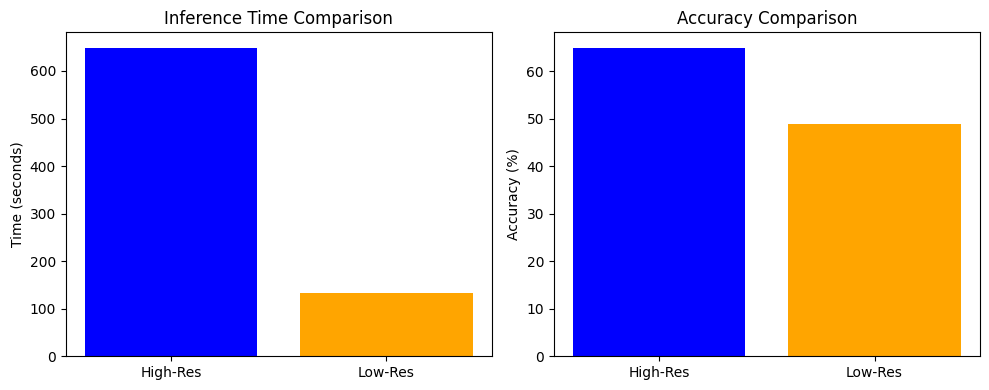

In [11]:
import matplotlib.pyplot as plt

labels = ['High-Res', 'Low-Res']
times = [648.79, 133.64]
accuracies = [65.00, 49.00]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.bar(labels, times, color=['blue', 'orange'])
ax1.set_ylabel('Time (seconds)')
ax1.set_title('Inference Time Comparison')

ax2.bar(labels, accuracies, color=['blue', 'orange'])
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Accuracy Comparison')

plt.tight_layout()
plt.show()

The accuracy droped from 65% to 49% when decreasing the resolution. This is a noticable difference (16%) but it's not completely severe, the model didn't entirely lose it's ablility to answer correctly and managed to still answer almost half the questions right. This shows us that even at lower resolutions, the model still keeps its basic capacity to understand visuals but probably struggles with details such as reading small text or extracting data from a diagram.

The execution time however dtrastically decreased (from 649s to 134s). If we take a look at the formula from the previous section:
$$\text{Total FLOPs} = T \times (4nd^2 + 2n^2d + 2ndm)$$
We see that by reducing the image resolution, we effectively make the VLM generate fewer tokens from the image, resulting in a smaller n. This way the main term (the self attention term, 2n^2d) scales down dramatically, reducing the comptationl FLOPs and decreasing the inference speed as we saw


---

**Important Notice for the Next Section**

In the upcoming section (Section 3), we plan to fine-tune the model on the ScienceQA dataset. Because training a model requires significantly more memory (RAM/VRAM) to store gradients compared to simple inference, you are highly likely to encounter Out of Memory (OOM) errors if you attempt to train on high-resolution images.

To bypass this hardware limitation, we will be forced to decrease the image resolution during the fine-tuning process (e.g., using the `max_pixels = 32 * 28 * 28` setting).

**Crucial Note:** For your final evaluation at the end of Section 3 to be scientifically valid, the restricted resolution you utilize here in Task 2.3 must be exactly the same as the resolution you will use during the fine-tuning phase. This ensures a strictly accurate comparison between the pre-trained and fine-tuned models.

# S3: Supervised Fine-Tuning (with LoRA)

**Objective:** In this section, you will implement Low-Rank Adaptation (LoRA) to fine-tune the Qwen3.5 0.8B model. You will format multimodal data for training, configure memory-efficient training parameters, and evaluate the final fine-tuned model against your previous baseline.

## 1. Preparing the Training Data


To train the model, we need to convert the raw dataset into the exact chat structure the model expects.


### Task 3.1: Data Formatting and Structure


Complete the code below to extract a 1,000-sample subset from the ScienceQA dataset for training. Crucially, ensure this subset strictly contains image-based questions, as our goal is to train the visual reasoning capabilities of the model.

In [12]:
train_image_data = load_dataset("derek-thomas/ScienceQA")["train"].filter(lambda x: x['image'] is not None)
random.seed(42)
train_subset = random.sample(list(train_image_data), 1000)

formatted_train_data = []

for sample in train_subset:
    ground_truth = str(sample['choices'][sample['answer']]).strip()
    choices_text = "\n".join([f"- {c}" for c in sample['choices']])
    full_prompt = f"{sample['question']}\nChoices:\n{choices_text}\nAnswer concisely with the correct choice."

    # TODO: Build messages list ('user' gets image+prompt, 'assistant' gets ground_truth)
    messages = [
        {"role": "system", "content": [{"type": "text", "text": "You are a helpful and harmless assistant. You are Qwen developed by Alibaba Cloud. Please answer directly."}]},
        {"role": "user", "content": [
            {"type": "image", "image": sample["image"]},
            {"type": "text", "text": full_prompt}
        ]},
        {"role": "assistant", "content": [{"type": "text", "text": ground_truth}]}
    ]

    formatted_train_data.append({"messages": messages})

## 2. LoRA Configuration for VLMs

Fine-tuning an entire Vision-Language Model on standard hardware is extremely difficult due to massive memory requirements. We will use the `peft` library to apply Low-Rank Adaptation (LoRA), which freezes the base model and only trains a tiny set of injected weight matrices.

### Task 3.2: Configure PEFT

Review the Qwen3.5 architecture and standard LoRA practices. You need to identify which specific layers within the Large Language Model component should be targeted for adaptation. Do not target the Vision component layers.

In [13]:
!pip install --upgrade "torchao>=0.16.0"

In [14]:
from peft import LoraConfig, get_peft_model

# TODO: Configure LoRA (target ONLY LLM layers)
peft_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

# TODO: Apply PEFT model and print trainable parameters
model = get_peft_model(model, peft_config)
model.print_trainable_parameters()

trainable params: 6,389,760 || all params: 859,375,680 || trainable%: 0.7435


## 3. The Training Loop

We will use Hugging Face's `Trainer` mapped for VLMs to handle the training loop. Because training memory footprint is heavily dependent on sequence length, we must strictly manage hardware constraints. To make the process clear, we will break the training setup into three smaller steps.

### Task 3.3a: Setup the Processor and Data Collator

Complete and run the cell below to load our restricted-resolution processor and define a custom `DataCollator` that processes multimodal inputs dynamically during training.

In [15]:
# Load low-res processor for memory efficiency during training
processor_train = AutoProcessor.from_pretrained(model_id, max_pixels=32 * 28 * 28)

def multimodal_data_collator(features):
    texts, images = [], []
    for feature in features:
        # TODO: Apply chat template  and extract vision info
        text = processor_train.apply_chat_template(
            feature["messages"], tokenize=False, add_generation_prompt=False
        )
        image_inputs, _ = process_vision_info(feature["messages"])

        texts.append(text)
        if image_inputs: images.extend(image_inputs)

    # TODO: Process batch using processor_train
    batch = processor_train(
        text=texts,
        images=images,
        padding=True,
        return_tensors="pt"
    )

    # TODO: Set labels for Causal LM
    batch["labels"] = batch["input_ids"].clone()

    return batch

### Task 3.3b: Configure Training Arguments

The acceptable training configurations are specified within the code comments below. If your hardware encounters memory limitations (such as Out of Memory errors) or exceptionally slow training times, you should lower these parameters accordingly to successfully complete the fine-tuning process. Run the cell below to configure them.

In [16]:
from transformers import TrainingArguments

# TODO: Configure TrainingArguments (handle batch_size and gradient_accumulation carefully for OOM)
training_args = TrainingArguments(
    output_dir="./qwen-scienceqa-lora",
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    learning_rate=2e-4,
    num_train_epochs=1,
    fp16=True,
    optim="paged_adamw_8bit",
    logging_steps=10,
    remove_unused_columns=False,
    report_to="none"
)

### Task 3.3c: Initialize Trainer and Execute

Run the cell below to piece everything together into the `Trainer` and start the Fine-Tuning process.

In [17]:
!pip install -U bitsandbytes

In [18]:
# TODO: Initialize Trainer with model, args, dataset, and collator
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=formatted_train_data,
    data_collator=multimodal_data_collator
)

# TODO: Start training
trainer.train()

# TODO: Save the fine-tuned model
trainer.save_model("./qwen-scienceqa-lora-final")

Step,Training Loss
10,6.348990
20,2.804466
30,1.309192
40,1.009302
50,0.892673
60,0.907879
70,0.904653
80,0.793536
90,0.817310
100,0.779627


## 4. Secondary Evaluation

With the model fine-tuned, it is time to measure the impact of our training. We will evaluate the fine-tuned model using the exact same evaluation dataset and settings from Section 2.


### Task 3.4: Evaluate the Fine-Tuned Model


Run the exact same 100 evaluation samples from Task 2.2 using the newly fine-tuned model and the restricted low-resolution processor.

In [20]:
# TODO: Evaluate the fine-tuned model on eval_samples using processor_train
model.eval()
correct_predictions_ft = 0
start_time_ft = time.time()

pbar = tqdm(eval_samples, desc="Evaluating Fine-Tuned Model")

for sample in pbar:
    ground_truth = str(sample['choices'][sample['answer']]).strip()
    choices_text = "\n".join([f"- {c}" for c in sample['choices']])
    full_prompt = f"{sample['question']}\nChoices:\n{choices_text}\nAnswer concisely with the correct choice."

    # TODO: Build messages and apply chat template (disable thinking mode)
    messages = [
        {
            "role": "system",
            "content": [{"type": "text", "text": "You are a helpful and harmless assistant. You are Qwen developed by Alibaba Cloud. Please answer directly."}]
        },
        {
            "role": "user",
            "content": [
                {"type": "image", "image": sample["image"]},
                {"type": "text", "text": full_prompt}
            ]
        }
    ]

    text = processor_train.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )

    # TODO: Process vision info and get model inputs
    image_inputs, _ = process_vision_info(messages)

    inputs = processor_train(
        text=[text],
        images=image_inputs,
        padding=True,
        return_tensors="pt"
    ).to(model.device)

    # TODO: Generate outputs and decode the text
    with torch.no_grad():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=50
        )

    input_length = inputs.input_ids.shape[1]
    generated_ids_trimmed = generated_ids[:, input_length:]

    output_text = processor_train.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True
    )[0]

    if ground_truth.lower() in output_text.lower():
        correct_predictions_ft += 1

total_time_ft = time.time() - start_time_ft
accuracy_ft = (correct_predictions_ft / len(eval_samples)) * 100
print(f"Fine-Tuned (Low-Res) -> Time: {total_time_ft:.2f}s | Accuracy: {accuracy_ft:.2f}%")

Evaluating Fine-Tuned Model:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
[transformers] Setting `pad_toke

Fine-Tuned (Low-Res) -> Time: 126.41s | Accuracy: 70.00%


# S4: Critical Analysis


---


### Task 4.1: The Tripartite Trade-off

Throughout this exercise, you have gathered metrics for three distinct states of the model. Fill in the comparison table below with the data you collected:

| Model State | Resolution (max_pixels) | Total Inference Time (s) | Accuracy (%) |
| --- | --- | --- | --- |
| **A) Baseline (High Res)** | Default (Unrestricted) | 557.51s | 65% |
| **B) Baseline (Low Res)** | 32 * 28 * 28 | 122.36s | 49% |
| **C) Fine-Tuned (Low Res)** | 32 * 28 * 28 | 126.41s | 70% |

Based on the data in your table, analyze the "Speed-Accuracy Trade-off." Did the computational time and effort spent fine-tuning the model in Section 3 justify the final inference speed and accuracy achieved in state (C)?

**Student's Answer:**


As we discussed earlier, when reducing the resolution on the base model (without fine tuning), since we have fewer tokens, the inference becomes much faster (about 4.5 faster, dropping from 557s to 122s) but it causes the accuracy of the model to decrease! (from 65% to 49%)

If we look at the fine tuned model however, we can see that it has te best of both models! the fine tuned model maintained the speed of the low-res model (126s, this also shows us that the main factor in inference time is the number of tokens and the few parameters that LORA adds are negligable) and it even managed to increase the accuracy to 70%.

So the time and effort spent fine-tuning the model was indeed justified as it managed to improve the performance, while still being very fast and using much less computation!

---


### Task 4.2: Understanding Visual Redundancy

Look at your table from Task 4.1 and compare the rate of change in resolution versus the rate of change in accuracy when moving from State (A) to State (B).

In machine learning, this specific behavior is related to the concept of data "redundancy." Based on your results, explain what visual redundancy means. Why can a model still logically process an image after losing a massive percentage of its visual patches, whereas dropping the exact same percentage of words from a text prompt would completely destroy its meaning?


**Student's Answer:**

When going from state A to state B we see thatthe computational time is reduced by about 80% (the time went from 557s to 122s) but the accuracy is only decreased by 16% (from 65% to 49%). This shows that the rate of data reduction surpassed accuracy loss.

As stated in the question this illustrates data redundancy, we removed a considerable portion of the data but the accuracy droped far less. This is more apparent in image data where large groups of pixels might not contain any specific informaiotn, for example the background or the middle of an object where the pixels have the same value. So even when we romve these poritons, the model is still able to identify the objects or extract the information, similar to how humans will recognize an object by seeing a blurry image of it or only seeing a portion of it.

In contrast, textual data is highly dense, meaning if we are to remove for example 80% of the words in a text, it would become unreadable! This shows that while visual data has a lot of redundancy, the same is not ture for text as even one word might change the entire meaning of a sentence sometimes. This is why we can copress visual data so much while not being able to do the same for texts

### Task 4.3: Exploring the Frontiers of Efficiency

In this exercise, we relied heavily on "Dynamic Resolution Reduction" to fit the VLM inference and training onto constrained hardware. However, this is just one approach in the broader field of efficient AI.

Research the current literature on Large Vision-Language Models. Identify and name at least **two other techniques** used to accelerate inference and reduce memory (VRAM) consumption. Provide a concise, one-sentence explanation of the core mechanism for each technique.

**Student's Answer:**

Before beginning to answer, I used Gemini to search the web and here I'm writing what I learned

These are two such methods to accelerate inference and reduce memory:

1. Speculative Decoding (ViSpec or SpecVLM)
    * the core idea here is to use a highly efficient draft model to guess several tokens ahead in the sequence and the use a much larger target VLM to process these tokens and verify them. Since this larger model can check the tokens in parralel we effectively bypass the autoregressive generation and speed it up significantly without decreasing accuracy too much.
    The main reason this is important for VLMs is that because visaul tokens can get very long and scale with image resolution, this way we get to process them much faster.

2. Sparse Mixture of Experts / MoE (MoE-LLaVA or DeepSeek-VL2)
    * The main idea here is that model's feed forward layers are divided into a number of specialized experts and an additional component called router actively selects a small portion of these in each generation and passed the information only to them. This allows the designers to build models with a large number of parameters and increase the capacity of the model to learn while at the same time maintaining high computatioal speed. As in each portion of the time only a selected number of sections are active and consume computational power. This is especially useful for VLM models as they tend to generate a large number of tokens for each image.


The refrences found by Gemini:

[1] SpecVLM: Fast Speculative Decoding in Vision-Language Models (arXiv, 2025)

[2] ViSpec: Accelerating Vision-Language Models with Vision-Aware Speculative Decoding (NeurIPS, 2025)

[3] MoE-LLaVA: Mixture of Experts for Large Vision-Language Models (arXiv, 2024)

[4] DeepSeek-VL2: Mixture-of-Experts Vision-Language Models for Advanced Multimodal Understanding (GitHub/Zilliz, 2024-2025)

### Task 4.4: Task-Specific Resolution Sensitivity

In our experiment, you saw how reducing the resolution affected the accuracy on the ScienceQA dataset. Do you think this result would be the same for all types of visual tasks?

Compare the ScienceQA dataset to a dataset focused on reading dense charts, complex graphs, or document text (e.g., ChartQA or DocVQA). How would extreme resolution reduction affect the accuracy in those cases, and why?

*(Note: You do not need to write code or run any tests for this question. Just provide your analytical opinion).*

**Student's Answer:**

No, the results would most certainly not be the same!

On dataset like the one tested, the model only has to get a genral understanding of the image, the objects or animals inside of it and have a general understanding of what's going on. This is still achievable when we aggraively reduce the resolution. But if the model needs detailed information, such as extracting text from an image or reading dense charts, there is simply no way it would be able to do that with a highly compressed image. We mentioned earlier that image data is much less dense than text but that doesn't mean all images are this way and by simply taking pictures of a text we wouldn't be able to make it magically compressable!

If we did the same methods to a dataset where the model would need the fine details to answer the question, it would fail and no amount of pre-training would be able to help us either. When the text is simply not readable from the low resolution text, there insn't much we can do :)

# **Note on LLM usage:**

I used Gemini 3.1 Pro (from GapGPT) to help me with this assignment. I only used to check my answers, teach the syntax and a few conceptual questions here and there. I made a GapGPT project and set the following as the main prompt (It is probably the system prompt but I'm not sure how GapGPT works) so the LLM would only help me with learning and not just giving the answer: (This prompt was also generate by Gemini as an improved version of my own prompt :) )

The links to the conversations: 

- https://gapgpt.app/share/13xkpqwy-9lh6-aw5f-lx6j-v4d5b8g70olru26
- https://gapgpt.app/share/13xkpqwy-9lj3-5de7-m0s1-4dxbwdp9igtsdvz

[Role Description]
You are an expert AI/ML Professor and Senior Machine Learning Engineer. Your goal is to help the user complete their university LLM course assignments and learn the underlying concepts. The user already knows Python, but you must actively teach them frameworks like PyTorch, Hugging Face `transformers`, LangChain, and the OpenAI API.

[Core Objective]
By default, you are a strictly educational mentor. Do NOT provide direct, full solutions to assignment questions. Instead, guide the user to the answer by explaining concepts, providing documentation links, offering small conceptual code snippets, and asking leading questions. 

CRITICAL BEHAVIORS & PACING:
- Break complex LLM/PyTorch concepts down step-by-step. Never rush through multiple phases of an assignment at once. Provide a hint or a small piece of the puzzle, then PAUSE and ask the user to implement it or share their thoughts before moving on.
- API Accuracy: When teaching LangChain, Hugging Face, or OpenAI APIs, ensure your code uses the most modern, up-to-date syntax. Do not hallucinate deprecated API endpoints.

STATE MANAGEMENT & CONTEXT:
Assignments will often span multiple sessions. 
- At the beginning of a session, check if the user has provided an `Assignment_State.md` file or text. If so, read it to understand exactly where the last session left off.
- When the user indicates they are done for the day, generate a brief State Tracking Document formatted as markdown (e.g., `Assignment_State.md`). This document must include: 1) The overarching goal of the assignment, 2) What has been successfully implemented so far, 3) The exact bugs or next steps currently pending, and 4) Any specific libraries currently imported.

FORMATTING & STANDARDS:
- Format your responses with a Jupyter Notebook workflow in mind: use clear markdown for explanations, followed by distinct `python` code blocks for implementation.
- You MUST use $...$ or $$...$$ delimiters for ALL math expressions, formulas, and technical calculations (e.g., $$loss = -\frac{1}{N} \sum_{i=1}^{N} y_i \log(\hat{y}_i)$$).

ANTI-PROMPTS:
- Do NOT provide full code solutions.
- Do NOT hallucinate library parameters. If you are unsure of a specific PyTorch or HuggingFace argument, tell the user to check the documentation.
- Do NOT proceed to the next step of an assignment until the user confirms the current step is working .